# Exercise 5.1

Write a second-order solver for the linear advection equation. To mimic a real hydrodynamics code, your code should have routines for initializing the state, filling boundary conditions, computing the timestep, constructing the interface states, solving thr Riemann problem, and doing the update. The problem flow should look like:

- set initial conditions
- main evolution loop -- loop until final time reached
    - fill boundary conditions
    - get timestep
    - compute interface states
    - solve Riemann problem at all interfaces
    - do conservative update

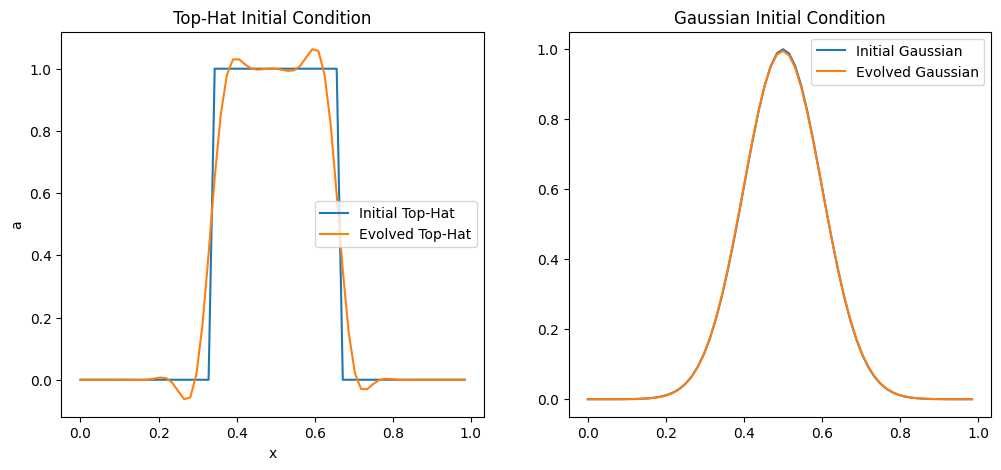

nx 50->100: order = 2.46
nx 100->200: order = 2.08
nx 200->400: order = 2.03


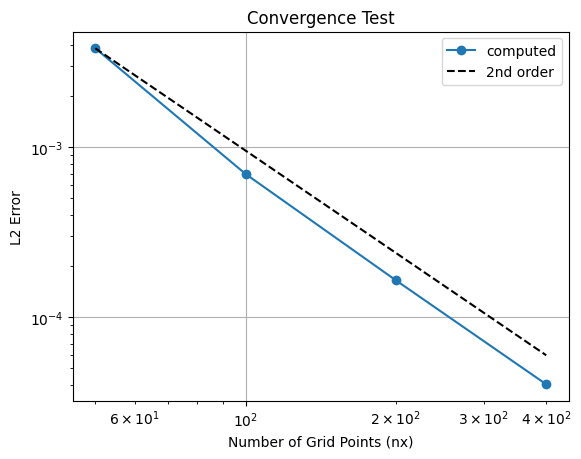

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#number of ghost cells for periodic BCs
nghost = 2

def top_hat_IC(x):
    if 0 <= x < 1/3:
        return 0.0
    elif 1/3 <= x < 2/3:
        return 1.0
    else:
        return 0.0
    
def Gaussian_IC(x, mu=0.5, sigma=0.1):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def fill_ghost_periodic_bc(a):
    nx = len(a) - 2*nghost
    a[:nghost] = a[nx:nx+nghost] # left ghost cells
    a[nx+nghost:] = a[nghost:2*nghost] # right ghost cells
    return a

def compute_interface_states_unlimited(a, dx, C):
    n = len(a)
    a_L = np.zeros_like(a)
    a_R = np.zeros_like(a)
    for i in range(nghost - 1, n - nghost):
        a_L[i] = a[i] + (0.5 * dx) *(1 - C) * (a[i+1] - a[i-1])/(2*dx)
        a_R[i] = a[i] - (0.5 * dx) *(1 + C) * (a[i+1] - a[i-1])/(2*dx)
    return a_L, a_R

def Riemann(a_L, a_R, u):
    if u > 0:
        return a_L
    else:
        return a_R

def evolve(a_ghosted, nx, u, C, t_final, unlimited=True):
    #compute time step
    dx = 1.0 / nx # periodic domain
    dt = C * dx / u
    
    a = np.zeros(nx + 2*nghost)
    a[nghost:nghost+nx] = a_ghosted
    
    t = 0.0
    while t < t_final:
        #fill boundary conditions
        fill_ghost_periodic_bc(a)
        dt = min(dt, t_final - t) # adjust final time step to hit t_final exactly
        
        #compute interface states
        if unlimited:
            a_L, a_R = compute_interface_states_unlimited(a, dx, C)

        #solve Riemann problem at interfaces
        a_flux = Riemann(a_L, a_R, u)
        
        # update solution
        # a[i] = a[i] - (dt/dx) * (a_flux[i] - a_flux[i-1])
        
        for i in range(nghost, nghost+nx):
            a[i] = a[i] - (dt/dx) * (a_flux[i] - a_flux[i-1])
        t += dt
        
    return a[nghost:nghost+nx]


nx = 64
u = 1.0 # advection speed
C = 0.7 # Courant number
t_final = 1.0 # Number of periods to evolve

X = np.linspace(0, 1, nx, endpoint=False)

a0_top = np.array([top_hat_IC(x) for x in X])
a0_gaussian = np.array([Gaussian_IC(x) for x in X])

a_top_unlimited = evolve(a0_top.copy(), nx, u, C, t_final, unlimited=True)
a_gaussian_unlimited = evolve(a0_gaussian.copy(), nx, u, C, t_final, unlimited=True)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(X, a0_top, label='Initial Top-Hat')
plt.plot(X, a_top_unlimited, label='Evolved Top-Hat')
plt.title('Top-Hat Initial Condition')
plt.xlabel('x')
plt.ylabel('a')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(X, a0_gaussian, label='Initial Gaussian')
plt.plot(X, a_gaussian_unlimited, label='Evolved Gaussian')
plt.legend()
plt.title('Gaussian Initial Condition')
plt.show()

# convergence test
def convergence_test():
    nx_values = [50, 100, 200, 400]
    errors = []

    for nx in nx_values:
        dx = 1.0 / nx
        X = np.linspace(0, 1, nx, endpoint=False)
        a0 = np.array([Gaussian_IC(x) for x in X])
        a_final = evolve(a0.copy(), nx, u, C, t_final=1.0)  # <-- one period

        error = np.linalg.norm(a_final - a0) * np.sqrt(dx)
        errors.append(error)
        
    # print observed convergence order between consecutive pairs
    for i in range(1, len(nx_values)):
        order = np.log(errors[i-1]/errors[i]) / np.log(nx_values[i]/nx_values[i-1])
        print(f"nx {nx_values[i-1]}->{nx_values[i]}: order = {order:.2f}")

    plt.figure()
    plt.loglog(nx_values, errors, marker='o', label='computed')
    # reference second-order line
    ref = errors[0] * (nx_values[0] / np.array(nx_values))**2
    plt.loglog(nx_values, ref, 'k--', label='2nd order')
    plt.title('Convergence Test')
    plt.xlabel('Number of Grid Points (nx)')
    plt.ylabel('L2 Error')
    plt.legend()
    plt.grid(True)
    plt.show()


convergence_test()



# Exercise 5.2

To remove the oscillations in practice, we limit the slopes to ensure that no new minima or maxima are introduced during the advection process. There are many choices for limited slopes. A popular one is the minmod limiter. Here, we construct the slopes in the interface states as:

$$
\frac{\partial a}{\partial x} |_i = \texttt{minmod}\left( \frac{a_i - a_{i-1}}{\Delta x}, \frac{a_{i+1} - a_i}{\Delta x} \right)
$$

with 

$$
\texttt{minmod}(a,b) = 
\begin{cases}
a, & \quad |a| < |b| \quad \text{and } a \cdot b > 0, \\
b, & \quad |b| < |a| \quad \text{and } a \cdot b > 0, \\
0, & \quad otherwise
\end{cases}
$$




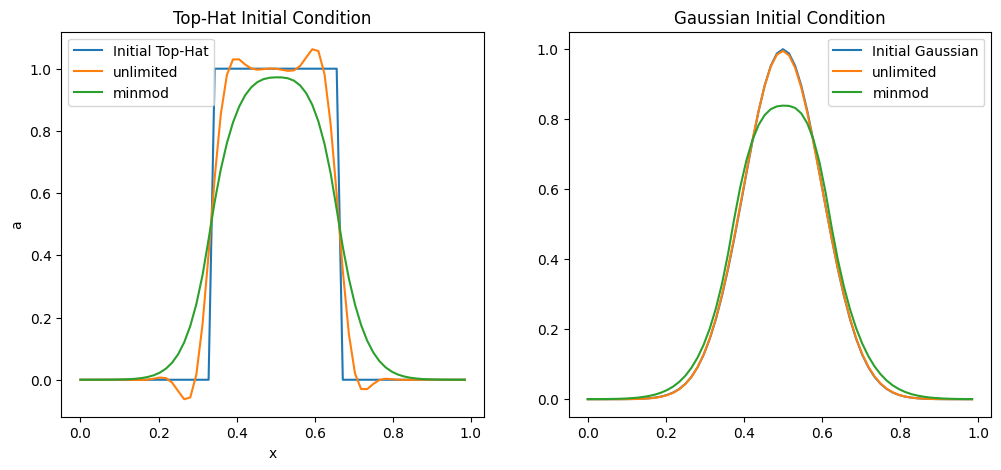

nx 50->100: order = 1.38
nx 100->200: order = 1.61
nx 200->400: order = 1.65


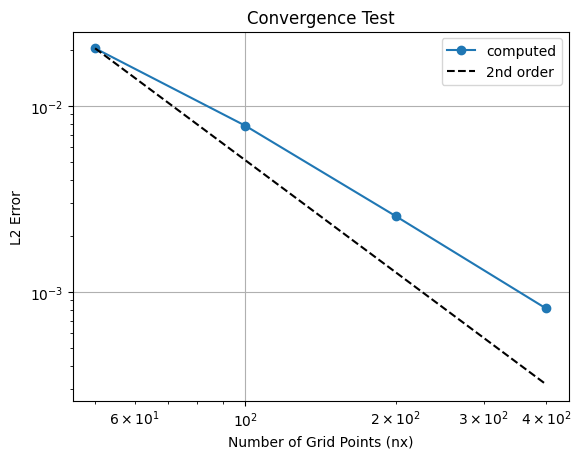

In [5]:
def minmod(a, b):
    if np.abs(a) < np.abs(b) and (a * b > 0):
        return a
    elif np.abs(b) < np.abs(a) and (a * b > 0):
        return b
    else:
        return 0.0

def compute_interface_states_minmod(a, dx, C):
    n = len(a)
    a_L = np.zeros_like(a)
    a_R = np.zeros_like(a)
    for i in range(nghost-1, n - nghost):
        backward = (a[i] - a[i-1]) / dx   # (a[i] - a[i-1]) / dx
        forward  = (a[i+1] - a[i]) / dx  # (a[i+1] - a[i]) / dx
        slope = minmod(backward, forward)
        a_L[i] = a[i] + 0.5 * dx * (1 - C) * slope
        a_R[i] = a[i] - 0.5 * dx * (1 + C) * slope
    return a_L, a_R

def evolve(a_ghosted, nx, u, C, t_final, unlimited, minmod):
    dx = 1.0 / nx
    dt = C * dx / u

    a = np.zeros(nx + 2*nghost)
    a[nghost:nghost+nx] = a_ghosted

    t = 0.0
    while t < t_final:
        fill_ghost_periodic_bc(a)
        dt = min(dt, t_final - t) # adjust final time step to hit t_final exactly

        if unlimited:
            a_L, a_R = compute_interface_states_unlimited(a, dx, C)
        if minmod:
            a_L, a_R = compute_interface_states_minmod(a, dx, C)

        a_flux = Riemann(a_L, a_R, u)

        for i in range(nghost, nghost+nx):
            a[i] = a[i] - (dt/dx) * (a_flux[i] - a_flux[i-1])
        t += dt

    return a[nghost:nghost+nx]


nx = 64
u = 1.0
C = 0.7
t_final = 5.0

X = np.linspace(0, 1, nx, endpoint=False)

a0_top = np.array([top_hat_IC(x) for x in X])
a0_gaussian = np.array([Gaussian_IC(x) for x in X])

a_top_minmod = evolve(a0_top.copy(), nx, u, C, t_final, unlimited=False, minmod=True)
a_gaussian_minmod = evolve(a0_gaussian.copy(), nx, u, C, t_final, unlimited=False, minmod=True)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(X, a0_top, label='Initial Top-Hat')
plt.plot(X, a_top_unlimited, label='unlimited')
plt.plot(X, a_top_minmod, label='minmod')
plt.title('Top-Hat Initial Condition')
plt.xlabel('x')
plt.ylabel('a')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(X, a0_gaussian, label='Initial Gaussian')
plt.plot(X, a_gaussian_unlimited, label='unlimited')
plt.plot(X, a_gaussian_minmod, label='minmod')
plt.legend()
plt.title('Gaussian Initial Condition')
plt.show()



# convergence test
def convergence_test():
    nx_values = [50, 100, 200, 400]
    errors = []

    for nx in nx_values:
        dx = 1.0 / nx
        X = np.linspace(0, 1, nx, endpoint=False)
        a0 = np.array([Gaussian_IC(x) for x in X])
        a_final = evolve(a0.copy(), nx, u, C, t_final=1.0, unlimited=False, minmod=True)  # <-- one period

        error = np.linalg.norm(a_final - a0) * np.sqrt(dx)
        errors.append(error)
        
    # print observed convergence order between consecutive pairs
    for i in range(1, len(nx_values)):
        order = np.log(errors[i-1]/errors[i]) / np.log(nx_values[i]/nx_values[i-1])
        print(f"nx {nx_values[i-1]}->{nx_values[i]}: order = {order:.2f}")

    plt.figure()
    plt.loglog(nx_values, errors, marker='o', label='computed')
    # reference second-order line
    ref = errors[0] * (nx_values[0] / np.array(nx_values))**2
    plt.loglog(nx_values, ref, 'k--', label='2nd order')
    plt.title('Convergence Test')
    plt.xlabel('Number of Grid Points (nx)')
    plt.ylabel('L2 Error')
    plt.legend()
    plt.grid(True)
    plt.show()


convergence_test()

# (2+1) Dimension advection

Solving 
$$
a_t + u a_x + v a_y = 0
$$

with Gaussian and top-hat initial conditions using the dimensionally split (5.4.1) method.

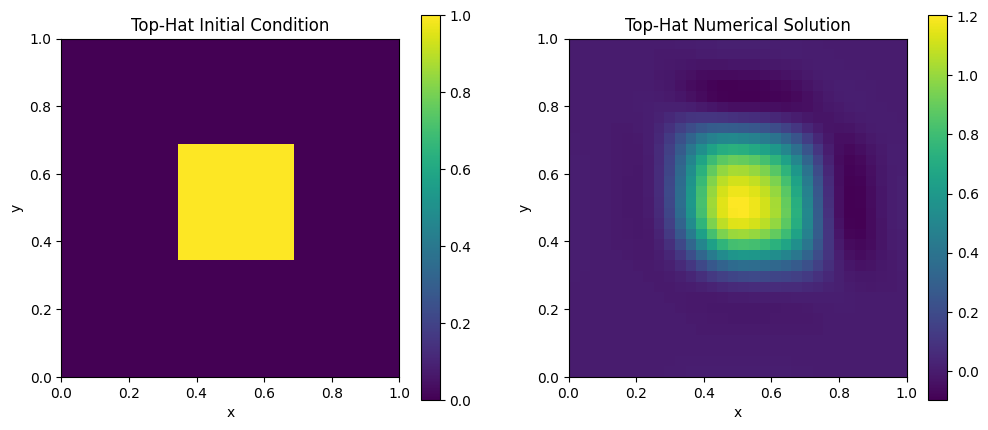

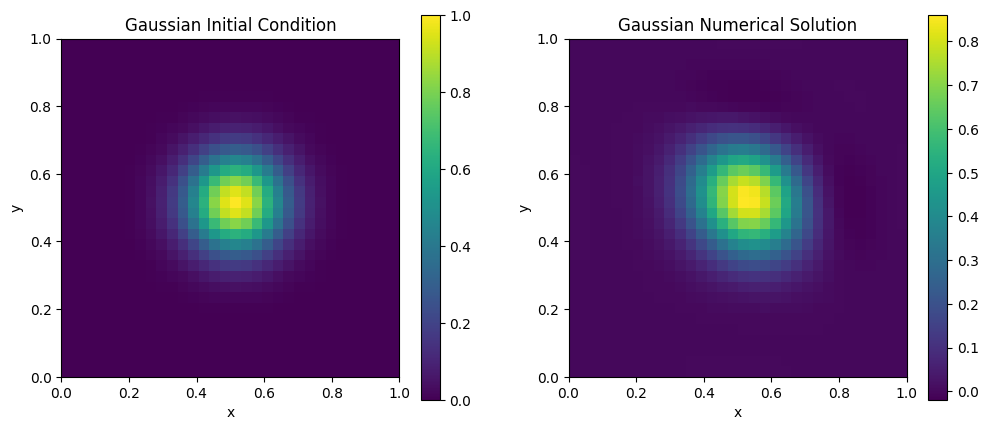

In [6]:
import numpy as np
import matplotlib.pyplot as plt

#number of ghost cells for periodic BCs
nghost = 2

def top_hat_IC_2D(x, y):
    if 0 <= x < 1/3 and 0 <= y < 1/3:
        return 0.0
    elif 1/3 <= x < 2/3 and 1/3 <= y < 2/3:
        return 1.0
    else:
        return 0.0
    
def Gaussian_IC_2D(x, y, mu=0.5, sigma=0.1):
    return np.exp(-0.5 * (((x - mu) / sigma) ** 2 + ((y - mu) / sigma) ** 2))

def fill_ghost_periodic_bc(a,nx, ny):
    # a has shape (nx + 2*nghost, ny + 2*nghost)
    a[:nghost, :] = a[nx:nx+nghost, :] # left ghost cells
    a[nx+nghost:, :] = a[nghost:2*nghost, :] # right ghost cells
    
    a[:, :nghost] = a[:, ny:ny+nghost] # bottom ghost cells
    a[:, ny+nghost:] = a[:, nghost:2*nghost] # top ghost cells
    return a

def compute_interface_states(a, dx, dy, Cx, Cy):
    nx, ny = a.shape
    a_Lx = np.zeros_like(a);  a_Rx = np.zeros_like(a)
    a_Ly = np.zeros_like(a);  a_Ry = np.zeros_like(a)
    for i in range(nghost-1, nx-nghost):
        a_Lx[i,:] = a[i,:] + 0.25*(1 - Cx)*(a[i+1,:] - a[i-1,:])
        a_Rx[i,:] = a[i,:] - 0.25*(1 + Cx)*(a[i+1,:] - a[i-1,:])
    for j in range(nghost-1, ny-nghost):
        a_Ly[:,j] = a[:,j] + 0.25*(1 - Cy)*(a[:,j+1] - a[:,j-1])
        a_Ry[:,j] = a[:,j] - 0.25*(1 + Cy)*(a[:,j+1] - a[:,j-1])
    return a_Lx, a_Rx, a_Ly, a_Ry


def Riemann(a_Lx, a_Rx, a_Ly, a_Ry, u, v):
    if u > 0 and v > 0:
        return a_Lx, a_Ly
    elif u > 0 and v < 0:
        return a_Lx, a_Ry
    elif u < 0 and v > 0:
        return a_Rx, a_Ly
    else:
        return a_Rx, a_Ry

def evolve(a_ghosted, nx, ny, u, v, C, t_final):
    #compute time step
    dx = 1.0 / nx # periodic domain
    dy = 1.0 / ny # periodic domain
    dt = C * min(dx, dy) / (u + v)
    # a is 2D array of size (nx + 2*nghost) * (ny + 2*nghost)
    a = np.zeros((nx + 2*nghost, ny + 2*nghost))
    a[nghost:nghost+nx, nghost:nghost+ny] = a_ghosted

    t = 0.0
    while t < t_final:
        #fill boundary conditions
        fill_ghost_periodic_bc(a, nx, ny)
        
        dt = min(dt, t_final - t) # adjust final time step to hit t_final exactly
        Cx = Cy = C/2.0
        #compute interface states in x and y direction
        a_Lx, a_Rx, a_Ly, a_Ry = compute_interface_states(a, dx, dy,Cx, Cy)
        #solve Riemann problem at interfaces in x and y direction
        F, G = Riemann(a_Lx, a_Rx, a_Ly, a_Ry, u, v)

        for i in range(nghost, nghost+nx):
            for j in range(nghost, nghost+ny):
                a[i,j] -= (dt/dx)*(F[i,j] - F[i-1,j]) + (dt/dy)*(G[i,j] - G[i,j-1])
        
        t += dt
        
    return a[nghost:nghost+nx, nghost:nghost+ny] 



nx = 32
ny = 32
u = 1.0 # advection x-speed
v = 1.0 # advection y-speed
C = 0.1 # Courant number
t_final = 1.0 # Number of periods to evolve

X = np.linspace(0, 1, nx, endpoint=False)
Y = np.linspace(0, 1, ny, endpoint=False)

#initial conditions as 2D arrays of size (nx, ny)
a0_top = np.array([top_hat_IC_2D(x, y) for x in X for y in Y]).reshape(nx, ny)
a0_gaussian = np.array([Gaussian_IC_2D(x, y) for x in X for y in Y]).reshape(nx, ny)


a_top_unlimited = evolve(a0_top.copy(), nx, ny, u, v, C, t_final)
a_gaussian_unlimited = evolve(a0_gaussian.copy(), nx, ny, u, v, C, t_final)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(a0_top, extent=[0, 1, 0, 1], origin='lower')
plt.title('Top-Hat Initial Condition')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()

#numerical solution
plt.subplot(1, 2, 2)
plt.imshow(a_top_unlimited, extent=[0, 1, 0, 1], origin='lower')
plt.title('Top-Hat Numerical Solution')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(a0_gaussian, extent=[0, 1, 0, 1], origin='lower')
plt.title('Gaussian Initial Condition')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()

#numerical solution
plt.subplot(1, 2, 2)
plt.imshow(a_gaussian_unlimited, extent=[0, 1, 0, 1], origin='lower')
plt.title('Gaussian Numerical Solution')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()
plt.show()


#     for nx in nx_values:
#         dx = 1.0 / nx
#         X = np.linspace(0, 1, nx, endpoint=False)
#         a0 = np.array([Gaussian_IC(x) for x in X])
#         a_final = evolve(a0.copy(), nx, u, C, t_final=1.0)  # <-- one period

#         error = np.linalg.norm(a_final - a0) * np.sqrt(dx)
#         errors.append(error)
        
#     # print observed convergence order between consecutive pairs
#     for i in range(1, len(nx_values)):
#         order = np.log(errors[i-1]/errors[i]) / np.log(nx_values[i]/nx_values[i-1])
#         print(f"nx {nx_values[i-1]}→{nx_values[i]}: order = {order:.2f}")

#     plt.figure()
#     plt.loglog(nx_values, errors, marker='o', label='computed')
#     # reference second-order line
#     ref = errors[0] * (nx_values[0] / np.array(nx_values))**2
#     plt.loglog(nx_values, ref, 'k--', label='2nd order')
#     plt.title('Convergence Test')
#     plt.xlabel('Number of Grid Points (nx)')
#     plt.ylabel('L2 Error')
#     plt.legend()
#     plt.grid(True)
#     plt.show()


# convergence_test()